# KSP Legacy Estimates - Business Intelligence

Analysis of 8,078 legacy Excel estimates extracted from `/Users/q/Documents/Work/KSP/Estimates/`.

**Data source:** `data/estimates/legacy_extract.json` (17MB, generated 2026-02-02)

In [100]:
import json
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load & Shape the Data

In [101]:
DATA_PATH = Path("../data/estimates/legacy_extract_refined.json")

with open(DATA_PATH) as f:
    raw = json.load(f)

print(f"Raw records: {len(raw)}")
print(f"Sample keys: {list(raw[0].keys())}")

Raw records: 8068
Sample keys: ['estimate_id', 'date', 'company_name', 'contact_name', 'job_description', 'reference', 'template_era', 'file_name', 'quantities', 'prices', 'unit_prices', 'profit_margin_pct', 'total_cost', 'product_type', 'size', 'materials', 'operations', 'finishing', 'printing', 'lamination', 'packing', 'delivery', 'cost_breakdown', 'parse_warnings', 'parse_confidence', 'financial_data_status']


In [102]:
# Flatten nested fields into a clean DataFrame
rows = []
for r in raw:
    row = {
        "estimate_id": r.get("estimate_id"),
        "date": r.get("date"),
        "job_description": r.get("job_description"),
        "product_type": r.get("product_type"),
        "total_cost": r.get("total_cost"),
        "profit_margin_pct": r.get("profit_margin_pct"),
        "quantity": r.get("quantities", [None])[0] if r.get("quantities") else None,
        "company": r.get("company_name"),
        "financial_data_status": r.get("financial_data_status"),
        "parse_confidence": r.get("parse_confidence"),
        "size": r.get("size_detected"),
        "template_era": r.get("template_era"),
        "quantity": r.get("quantities", [None])[0] if r.get("quantities") else None,
        "unit_price": r.get("unit_prices", [None])[0] if r.get("unit_prices") else None,
        "num_operations": len(r.get("operations", [])),
        "operations": r.get("operations", []),
        "num_cost_items": len(r.get("cost_breakdown", {})),
        "cost_breakdown": r.get("cost_breakdown", {}),
        "source_file": r.get("source_file")
    }
    rows.append(row)

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year_quarter"] = df["year"].astype("Int64").astype(str) + "-Q" + df["quarter"].astype("Int64").astype(str)

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (8068, 22)


,estimate_id,date,job_description,product_type,total_cost,profit_margin_pct,quantity,company,financial_data_status,parse_confidence,size,template_era,unit_price,num_operations,operations,num_cost_items,cost_breakdown,source_file,year,month,quarter,year_quarter
0,39881,2023-02-05 00:00:00+00:00,PHILLIPS 1 COLOUR & DIE CUT FREE ISSUE POLYPROPYLENE (2),None,290.13,20.00,"1,000.00",PHILLIPS,complete,0.80,None,2020_pob_master,NaN,6,"[screen_printing, cutting, creasing, assembly, drilling,...",18,"{'carriage:ADMIN / PRE PRESS': 5.0, 'carriage:MAC TIME I...",None,"2,023.00",2.00,1.00,2023-Q1
1,39881,2024-02-05 00:00:00+00:00,1 COL & DIE CUT FREE ISSUE POLYPROPYLENE,None,NaN,NaN,"1,000.00",PHILLIPS,quote_only,0.85,None,2024_quotation,0.35,0,[],0,{},None,"2,024.00",2.00,1.00,2024-Q1
2,44194,2017-03-07 00:00:00+00:00,PRINT SOURCE 10000 TO 20000 3 PART BOX,box,NaN,NaN,"20,000.00",CHRIS,quote_only,0.70,None,2017_box,1.24,16,"[administration charge, design/artwork/applemac/kasemake...",16,"{'ADMINISTRATION CHARGE': 5.0, 'DESIGN/ARTWORK/APPLEMAC/...",None,"2,017.00",3.00,1.00,2017-Q1
3,44267,2018-05-16 00:00:00+00:00,PHORMULA PAE KNOCK PRO ANALYSER LABEL.xlr,label,290.70,20.00,100.00,PHORMULA,complete,0.80,None,2020_pob_master,NaN,5,"[screen_printing, cutting, assembly, drilling, foil_bloc...",19,"{'carriage:ADMIN / PRE PRESS': 5.0, 'carriage:MAC TIME I...",None,"2,018.00",5.00,2.00,2018-Q2
4,44474,2019-06-20 00:00:00+00:00,RIGHT SIGNS SETS OF 3 OR 5 COL LABELS,label,817.96,20.00,"1,000.00",RIGHT SIGNS,complete,0.80,None,2020_pob_master,NaN,5,"[screen_printing, cutting, assembly, drilling, foil_bloc...",19,"{'carriage:ADMIN / PRE PRESS': 5.0, 'carriage:MAC TIME I...",None,"2,019.00",6.00,2.00,2019-Q2


In [103]:
# Data completeness overview
completeness = df.notna().mean().sort_values(ascending=False)
print("Field completeness:")
for col, pct in completeness.items():
    bar = "#" * int(pct * 40)
    print(f"  {col:25s} {pct:5.1%}  {bar}")

Field completeness:
  template_era              100.0%  ########################################
  financial_data_status     100.0%  ########################################
  cost_breakdown            100.0%  ########################################
  num_cost_items            100.0%  ########################################
  operations                100.0%  ########################################
  num_operations            100.0%  ########################################
  parse_confidence          100.0%  ########################################
  year_quarter              100.0%  ########################################
  company                   100.0%  ########################################
  job_description           100.0%  #######################################
  estimate_id               100.0%  #######################################
  date                      99.7%  #######################################
  year                      99.7%  #########################

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   estimate_id            8065 non-null   object             
 1   date                   8041 non-null   datetime64[ns, UTC]
 2   job_description        8065 non-null   object             
 3   product_type           5226 non-null   object             
 4   total_cost             6285 non-null   float64            
 5   profit_margin_pct      6383 non-null   float64            
 6   quantity               7736 non-null   float64            
 7   company                8068 non-null   object             
 8   financial_data_status  8068 non-null   object             
 9   parse_confidence       8068 non-null   float64            
 10  size                   0 non-null      object             
 11  template_era           8068 non-null   object           

## 2. Revenue Analysis

In [105]:
# Filter to records with valid cost and reasonable date range
priced = df[(df["total_cost"] > 0) & (df["year"] >= 2015) & (df["year"] <= 2025)].copy()
print(f"Priced estimates: {len(priced):,} / {len(df):,}")
print(f"Total revenue:    £{priced['total_cost'].sum():,.2f}")
print(f"Mean:             £{priced['total_cost'].mean():,.2f}")
print(f"Median:           £{priced['total_cost'].median():,.2f}")
print(f"Std:              £{priced['total_cost'].std():,.2f}")

Priced estimates: 6,262 / 8,068
Total revenue:    £18,606,649.34
Mean:             £2,971.36
Median:           £1,204.45
Std:              £5,885.74


In [106]:
# Annual revenue trend
annual = priced.groupby("year").agg(
    estimates=("total_cost", "count"),
    revenue=("total_cost", "sum"),
    avg_value=("total_cost", "mean"),
    median_value=("total_cost", "median"),
).reset_index()
annual

,year,estimates,revenue,avg_value,median_value
0,"2,016.00",2,615.41,307.71,307.71
1,"2,017.00",92,"245,117.45","2,664.32",980.51
2,"2,018.00",1078,"2,311,396.14","2,144.15",959.42
3,"2,019.00",1088,"2,062,956.27","1,896.10",803.13
4,"2,020.00",842,"2,323,169.89","2,759.11",915.52
5,"2,021.00",748,"2,755,752.92","3,684.16","1,478.84"
6,"2,022.00",817,"2,937,776.57","3,595.81","1,682.81"
7,"2,023.00",920,"3,696,917.22","4,018.39","1,617.37"
8,"2,024.00",674,"2,261,154.17","3,354.83","1,678.01"
9,"2,025.00",1,"11,793.30","11,793.30","11,793.30"


In [107]:
# Quarterly revenue trend
quarterly = priced.groupby(["year", "quarter"]).agg(
    estimates=("total_cost", "count"),
    revenue=("total_cost", "sum"),
).reset_index()
quarterly["label"] = quarterly["year"].astype(str) + "-Q" + quarterly["quarter"].astype(str)
quarterly

,year,quarter,estimates,revenue,label
0,"2,016.00",2.00,2,615.41,2016.0-Q2.0
1,"2,017.00",3.00,6,"15,316.33",2017.0-Q3.0
2,"2,017.00",4.00,86,"229,801.12",2017.0-Q4.0
3,"2,018.00",1.00,292,"779,620.02",2018.0-Q1.0
4,"2,018.00",2.00,241,"445,477.98",2018.0-Q2.0
5,"2,018.00",3.00,285,"614,688.94",2018.0-Q3.0
6,"2,018.00",4.00,260,"471,609.21",2018.0-Q4.0
7,"2,019.00",1.00,292,"411,622.63",2019.0-Q1.0
8,"2,019.00",2.00,291,"569,679.25",2019.0-Q2.0
9,"2,019.00",3.00,291,"677,021.23",2019.0-Q3.0


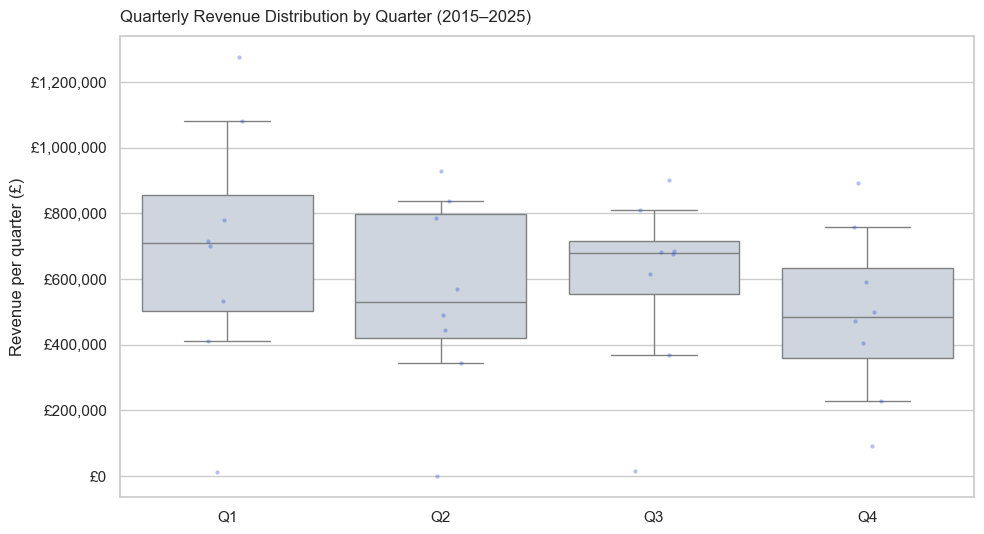

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

q = quarterly.copy()
q["quarter"] = q["quarter"].astype(int)
q["quarter_label"] = pd.Categorical(
    "Q" + q["quarter"].astype(str),
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True,
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(
    data=q,
    x="quarter_label",
    y="revenue",
    color="#CBD5E1",
    whis=(5, 95),
    showfliers=False,
    ax=ax
)
sns.stripplot(
    data=q,
    x="quarter_label",
    y="revenue",
    color="#1D4ED8",
    alpha=0.35,
    size=3,
    ax=ax
)

ax.set_title("Quarterly Revenue Distribution by Quarter (2015–2025)", loc="left", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Revenue per quarter (£)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:,.0f}"))

plt.tight_layout()
plt.show()

/var/folders/g0/5s73wq9x27b9qwvrczncd0hc0000gn/T/ipykernel_48232/4052397647.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q.groupby("quarter_label", as_index=False)


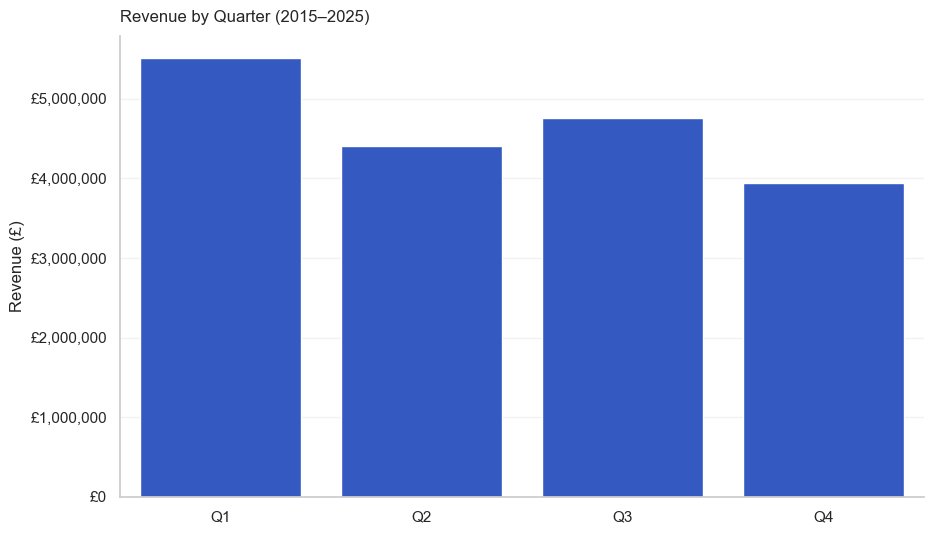

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Ensure ordered quarter labels
q = quarterly.copy()
q["quarter"] = q["quarter"].astype(int)
q["quarter_label"] = pd.Categorical(
    "Q" + q["quarter"].astype(str),
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True,
)

seasonality = (
    q.groupby("quarter_label", as_index=False)
     .agg(revenue=("revenue", "sum"), estimates=("estimates", "sum"))
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9.5, 5.5))

sns.barplot(
    data=seasonality,
    x="quarter_label",
    y="revenue",
    color="#1D4ED8",
    ax=ax
)

ax.set_title("Revenue by Quarter (2015–2025)", loc="left", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.grid(True, axis="y", alpha=0.25)
ax.grid(False, axis="x")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Customer Analysis

In [110]:
# Top 30 customers by revenue
customer_stats = priced.groupby("company").agg(
    estimates=("total_cost", "count"),
    revenue=("total_cost", "sum"),
    avg_order=("total_cost", "mean"),
    median_order=("total_cost", "median"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    avg_quantity=("quantity", "mean"),
).sort_values("revenue", ascending=False).reset_index()

customer_stats["tenure_days"] = (customer_stats["last_date"] - customer_stats["first_date"]).dt.days
customer_stats["revenue_pct"] = customer_stats["revenue"] / customer_stats["revenue"].sum() * 100
customer_stats["cumulative_pct"] = customer_stats["revenue_pct"].cumsum()

print(f"Unique customers: {len(customer_stats)}")
customer_stats.head(30)

Unique customers: 960


,company,estimates,revenue,avg_order,median_order,first_date,last_date,avg_quantity,tenure_days,revenue_pct,cumulative_pct
0,CELSUR,433,"1,356,931.53","3,133.79","1,153.06",2019-01-09 00:00:00+00:00,2022-11-01 00:00:00+00:00,"1,962.70",1392,7.29,7.29
1,MAXIPOS,142,"1,146,105.78","8,071.17","3,839.77",2022-05-13 00:00:00+00:00,2024-09-11 00:00:00+00:00,"6,064.08",852,6.16,13.45
2,BANBURY LITHO,182,"531,057.78","2,917.90","1,086.87",2017-11-02 00:00:00+00:00,2024-09-15 00:00:00+00:00,"1,581.30",2509,2.85,16.31
3,SEACOURT,78,"528,560.50","6,776.42","2,249.86",2018-01-22 00:00:00+00:00,2024-09-23 00:00:00+00:00,"8,185.94",2436,2.84,19.15
4,JLR,180,"527,084.38","2,928.25","1,198.51",2018-01-04 00:00:00+00:00,2024-09-25 00:00:00+00:00,"1,211.40",2456,2.83,21.98
5,ROBINSONS,63,"508,661.63","8,073.99","5,455.70",2020-08-27 00:00:00+00:00,2024-06-11 00:00:00+00:00,"16,840.63",1384,2.73,24.71
6,WETHERBY,131,"489,724.34","3,738.35","1,971.41",2022-07-11 00:00:00+00:00,2025-01-24 00:00:00+00:00,"3,410.49",928,2.63,27.35
7,PDS,131,"450,351.02","3,437.79","1,901.33",2018-01-05 00:00:00+00:00,2024-10-07 00:00:00+00:00,"5,903.76",2467,2.42,29.77
8,WE'RE FYI,38,"433,487.68","11,407.57","3,429.60",2020-11-26 00:00:00+00:00,2023-01-05 00:00:00+00:00,"9,413.95",770,2.33,32.10
9,DAYFOLD,36,"347,786.00","9,660.72","3,721.21",2023-07-13 00:00:00+00:00,2024-10-01 00:00:00+00:00,"15,800.00",446,1.87,33.97


In [111]:
# Pareto analysis - what % of customers drive 80% of revenue?
pareto_80 = customer_stats[customer_stats["cumulative_pct"] <= 80]
print(f"Top {len(pareto_80)} customers ({100*len(pareto_80)/len(customer_stats):.1f}%) generate 80% of revenue")
print(f"Their combined revenue: £{pareto_80['revenue'].sum():,.2f}")

Top 112 customers (11.7%) generate 80% of revenue
Their combined revenue: £14,857,188.77


In [112]:
# Customer recency - when did they last order?
latest_date = priced["date"].max()
customer_stats["days_since_last"] = (latest_date - customer_stats["last_date"]).dt.days

# Segment by activity
def segment(row):
    days = row["days_since_last"]
    orders = row["estimates"]
    revenue = row["revenue"]
    if days < 180 and orders >= 10 and revenue > 50000:
        return "champion"
    elif days < 365 and orders >= 5:
        return "loyal"
    elif days < 365:
        return "active"
    elif days < 730:
        return "at_risk"
    else:
        return "dormant"

customer_stats["segment"] = customer_stats.apply(segment, axis=1)

seg_summary = customer_stats.groupby("segment").agg(
    count=("company", "count"),
    total_revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
).sort_values("total_revenue", ascending=False)
seg_summary

,count,total_revenue,avg_revenue
segment,,,
dormant,639,"6,753,725.41","10,569.21"
champion,22,"5,769,574.31","262,253.38"
loyal,55,"2,972,143.39","54,038.97"
at_risk,148,"2,360,146.71","15,946.94"
active,96,"751,059.52","7,823.54"


## 4. Product & Operations Analysis

In [113]:
# Revenue by product type
product_rev = priced[priced["product_type"].notna()].groupby("product_type").agg(
    count=("total_cost", "count"),
    revenue=("total_cost", "sum"),
    avg_cost=("total_cost", "mean"),
    avg_quantity=("quantity", "mean"),
).sort_values("revenue", ascending=False)
product_rev

,count,revenue,avg_cost,avg_quantity
product_type,,,,
box,1525,"6,246,921.81","4,096.34","2,072.06"
binder,1570,"5,359,842.94","3,413.91","2,255.04"
sign,386,"619,506.77","1,604.94","1,633.20"
label,300,"338,402.36","1,128.01","7,866.18"
packaging,92,"302,562.97","3,288.73","5,612.40"
folder,79,"240,353.04","3,042.44","1,865.49"
divider,82,"115,927.97","1,413.76","2,880.10"


In [114]:
# Operations frequency across all estimates
ops_flat = priced.explode("operations")
ops_freq = ops_flat["operations"].value_counts().head(15)
print("Operation frequency:")
for op, count in ops_freq.items():
    pct = 100 * count / len(priced)
    print(f"  {op:35s} {count:5d} ({pct:.0f}%)")

Operation frequency:
  cutting                              6164 (98%)
  assembly                             6015 (96%)
  screen_printing                      5312 (85%)
  drilling                             4712 (75%)
  laminating                           3886 (62%)
  foil_blocking                        3837 (61%)
  wrapping                             3216 (51%)
  liner_gluing                         3142 (50%)
  creasing                             3003 (48%)
  set up paper over board machine        82 (1%)
  clean up paper over board machine      81 (1%)
  set platten in minutes                 54 (1%)
  make ready jetrix to print in minutes    54 (1%)
  number of minutes to load and unload bed of jetrix/total print time in minutes/hourly rate/total cost    54 (1%)
  prime each sheet, seconds per sheet    54 (1%)


In [115]:
# Average cost by number of operations (complexity proxy)
complexity = priced.groupby("num_operations").agg(
    count=("total_cost", "count"),
    avg_cost=("total_cost", "mean"),
    avg_quantity=("quantity", "mean"),
).reset_index()
complexity

,num_operations,count,avg_cost,avg_quantity
0,1,22,"3,620.11",457.14
1,2,2,"3,469.54",200.00
2,3,5,"12,677.24","18,400.00"
3,4,120,"4,331.29","9,469.51"
4,5,2299,"2,091.62","2,518.32"
5,6,1500,"3,258.56","3,802.23"
6,7,412,"5,086.49","3,811.34"
7,8,849,"4,014.61","2,892.95"
8,9,955,"2,661.88","1,974.08"
9,16,1,45.00,"2,000.00"


## 5. Pricing & Margin Analysis

In [116]:
# Unit price distribution
with_unit = priced[priced["unit_price"].notna() & (priced["unit_price"] > 0)].copy()
print(f"Estimates with unit price: {len(with_unit)}")
print(f"Unit price range: £{with_unit['unit_price'].min():.4f} - £{with_unit['unit_price'].max():.2f}")
print(f"Mean unit price:  £{with_unit['unit_price'].mean():.4f}")
print(f"Median unit price: £{with_unit['unit_price'].median():.4f}")

# Unit price by product type
unit_by_product = with_unit.groupby("product_type")["unit_price"].describe()
unit_by_product

Estimates with unit price: 2383
Unit price range: £0.0188 - £786.75
Mean unit price:  £10.9135
Median unit price: £3.8497


,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
binder,"1,345.00",7.44,23.33,0.24,1.84,3.37,6.97,733.11
box,556.00,20.86,45.04,0.27,4.79,11.95,21.31,786.75
divider,17.00,0.50,0.26,0.25,0.38,0.42,0.53,1.35
folder,54.00,16.42,41.94,0.32,1.46,5.59,11.23,272.15
label,17.00,0.85,1.08,0.02,0.07,0.38,1.05,3.16
packaging,26.00,4.05,7.23,0.20,0.28,0.43,6.25,32.41
sign,7.00,14.54,7.57,0.83,12.07,12.73,21.31,21.43


In [117]:
# Profit margin distribution
with_margin = priced[priced["profit_margin_pct"].notna() & (priced["profit_margin_pct"] > 0) & (priced["profit_margin_pct"] < 100)].copy()
print(f"Estimates with margin: {len(with_margin)}")
print(f"Mean margin:   {with_margin['profit_margin_pct'].mean():.1f}%")
print(f"Median margin: {with_margin['profit_margin_pct'].median():.1f}%")

# Margin by product type
margin_by_product = with_margin.groupby("product_type")["profit_margin_pct"].describe()
margin_by_product

Estimates with margin: 5250
Mean margin:   19.9%
Median margin: 20.0%


,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
binder,"1,259.00",16.86,7.58,1.00,10.00,20.00,20.00,71.50
box,"1,337.00",18.15,7.71,2.00,10.00,20.00,20.00,97.40
divider,74.00,20.50,9.37,5.00,20.00,20.00,20.00,50.00
folder,64.00,20.57,12.09,0.20,13.75,20.00,23.00,60.00
label,284.00,23.40,10.65,0.11,20.00,20.00,25.00,80.00
packaging,67.00,17.16,6.39,5.00,10.00,20.00,20.00,39.00
sign,332.00,24.28,12.06,3.00,20.00,20.00,27.50,94.00


In [118]:
# Quantity vs total cost relationship
qty_cost = priced[(priced["quantity"].notna()) & (priced["quantity"] > 0)].copy()
qty_cost["cost_per_unit"] = qty_cost["total_cost"] / qty_cost["quantity"]

# Quantity buckets
bins = [0, 100, 500, 1000, 5000, 10000, 50000, 100000]
labels = ["1-100", "101-500", "501-1K", "1K-5K", "5K-10K", "10K-50K", "50K+"]
qty_cost["qty_bucket"] = pd.cut(qty_cost["quantity"], bins=bins, labels=labels)

bucket_stats = qty_cost.groupby("qty_bucket", observed=True).agg(
    count=("total_cost", "count"),
    avg_total=("total_cost", "mean"),
    avg_unit_cost=("cost_per_unit", "mean"),
    median_unit_cost=("cost_per_unit", "median"),
).reset_index()
bucket_stats

,qty_bucket,count,avg_total,avg_unit_cost,median_unit_cost
0,1-100,1857,670.86,28.19,14.24
1,101-500,1827,"1,697.64",6.17,4.03
2,501-1K,847,"2,831.39",3.34,2.02
3,1K-5K,1109,"4,468.88",1.81,1.14
4,5K-10K,267,"8,700.16",1.07,0.86
5,10K-50K,216,"13,540.37",0.60,0.52
6,50K+,42,"22,375.17",0.33,0.32


## 6. Seasonality & Trends

In [119]:
# Monthly seasonality (across all years)
monthly_season = priced.groupby("month").agg(
    estimates=("total_cost", "count"),
    revenue=("total_cost", "sum"),
    avg_value=("total_cost", "mean"),
).reset_index()
monthly_season["month_name"] = monthly_season["month"].map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
})
monthly_season

,month,estimates,revenue,avg_value,month_name
0,1.00,612,"1,839,196.35","3,005.22",Jan
1,2.00,643,"1,873,183.81","2,913.19",Feb
2,3.00,583,"1,798,751.09","3,085.34",Mar
3,4.00,434,"1,174,261.98","2,705.67",Apr
4,5.00,536,"1,722,766.37","3,214.12",May
5,6.00,570,"1,506,025.25","2,642.15",Jun
6,7.00,614,"1,908,088.46","3,107.64",Jul
7,8.00,461,"1,549,395.66","3,360.95",Aug
8,9.00,463,"1,297,407.71","2,802.18",Sep
9,10.00,519,"1,425,085.54","2,745.83",Oct


In [120]:
# Year-over-year growth
yoy = annual.copy()
yoy["revenue_growth"] = yoy["revenue"].pct_change() * 100
yoy["volume_growth"] = yoy["estimates"].pct_change() * 100
yoy

,year,estimates,revenue,avg_value,median_value,revenue_growth,volume_growth
0,"2,016.00",2,615.41,307.71,307.71,NaN,NaN
1,"2,017.00",92,"245,117.45","2,664.32",980.51,"39,729.81","4,500.00"
2,"2,018.00",1078,"2,311,396.14","2,144.15",959.42,842.97,"1,071.74"
3,"2,019.00",1088,"2,062,956.27","1,896.10",803.13,-10.75,0.93
4,"2,020.00",842,"2,323,169.89","2,759.11",915.52,12.61,-22.61
5,"2,021.00",748,"2,755,752.92","3,684.16","1,478.84",18.62,-11.16
6,"2,022.00",817,"2,937,776.57","3,595.81","1,682.81",6.61,9.22
7,"2,023.00",920,"3,696,917.22","4,018.39","1,617.37",25.84,12.61
8,"2,024.00",674,"2,261,154.17","3,354.83","1,678.01",-38.84,-26.74
9,"2,025.00",1,"11,793.30","11,793.30","11,793.30",-99.48,-99.85


## 7. Data Quality Summary

In [121]:
# Template era distribution and extraction quality
quality = df.groupby("template_era").agg(
    count=("company", "count"),
    has_cost=("total_cost", lambda x: x.notna().sum()),
    has_company=("company", lambda x: x.notna().sum()),
    has_quantity=("quantity", lambda x: x.notna().sum()),
    has_operations=("num_operations", lambda x: (x > 0).sum()),
    avg_confidence=("parse_confidence", "mean"),
).reset_index()

for col in ["has_cost", "has_company", "has_quantity", "has_operations"]:
    quality[f"{col}_pct"] = (quality[col] / quality["count"] * 100).round(1)

quality

,template_era,count,has_cost,has_company,has_quantity,has_operations,avg_confidence,has_cost_pct,has_company_pct,has_quantity_pct,has_operations_pct
0,2017_box,113,98,113,56,112,0.70,86.70,100.00,49.60,99.10
1,2020_pob_master,6469,6187,6469,6303,6330,0.80,95.60,100.00,97.40,97.90
2,2024_quotation,1486,0,1486,1377,0,0.85,0.00,100.00,92.70,0.00


In [122]:
# Records with missing total_cost - investigate
missing_cost = df[df["total_cost"].isna()]
print(f"Records missing total_cost: {len(missing_cost)}")
print(f"\nBy template era:")
print(missing_cost["template_era"].value_counts())
print(f"\nBy year:")
print(missing_cost["year"].value_counts().sort_index())

Records missing total_cost: 1783

By template era:
template_era
2024_quotation     1486
2020_pob_master     282
2017_box             15
Name: count, dtype: int64

By year:
year
2,017.00      5
2,018.00     41
2,019.00     30
2,020.00     15
2,021.00      9
2,022.00     12
2,023.00    906
2,024.00    755
Name: count, dtype: int64


In [125]:
SAVE_PATH = "/Users/q/PythonScript/Python/Vibe/products/ksp-packaging-estimator/data/companies/customer_stats.csv"
customer_stats.drop(columns=["first_date", "last_date"], axis=1)
customer_stats.to_csv(SAVE_PATH, index=False)